In [1]:
#Kitabxanalar
!pip install -q transformers datasets jiwer librosa soundfile tqdm accelerate evaluate
!pip install -q -U huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 10.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 77.5 MB/s eta 0:00:00:00:01


In [2]:
#İmport-lar
import os
import re
import json
import unicodedata
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch
from transformers import (
    WhisperForConditionalGeneration,
    WhisperProcessor,
    WhisperFeatureExtractor,
    WhisperTokenizer,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
)
from datasets import load_dataset, Audio
import evaluate
from jiwer import wer as jwer, cer as jcer
warnings.filterwarnings('ignore')

In [3]:
#GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [4]:
#Output qovluqları 
OUTPUT_DIR     = '/kaggle/working/results_b'   if os.path.exists('/kaggle/working') else 'results_b'
CHECKPOINT_DIR = '/kaggle/working/whisper-az-ft' if os.path.exists('/kaggle/working') else 'whisper-az-ft'
os.makedirs(OUTPUT_DIR,     exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [5]:
#Konfiqurasiya 
MODEL_ID      = 'openai/whisper-small'
LANGUAGE      = 'azerbaijani'
LANGUAGE_CODE = 'az'
DATASET_NAME  = 'google/fleurs'
FLEURS_CODE   = 'az_az'
SAMPLE_RATE   = 16_000

TRAIN_SAMPLES = 200
VAL_SAMPLES   = 50
TEST_SAMPLES  = 100   

TRAIN_BATCH   = 8
EVAL_BATCH    = 8
NUM_EPOCHS    = 10
LEARNING_RATE = 1e-5
WARMUP_STEPS  = 50
SAVE_STEPS    = 10     
EVAL_STEPS    = 10     

print(f'Model     : {MODEL_ID}')
print(f'Train     : {TRAIN_SAMPLES} | Val: {VAL_SAMPLES} | Test: {TEST_SAMPLES}')
print(f'Epochs    : {NUM_EPOCHS} | LR: {LEARNING_RATE} | Eval steps: {EVAL_STEPS}')

Model     : openai/whisper-small
Train     : 200 | Val: 50 | Test: 100
Epochs    : 10 | LR: 1e-05 | Eval steps: 10


In [6]:
#Dataset  
def load_split(split, n):
    ds = load_dataset(DATASET_NAME, FLEURS_CODE, split=split, streaming=True)
    ds = ds.cast_column('audio', Audio(sampling_rate=SAMPLE_RATE))
    samples = []
    for item in tqdm(ds.take(n), total=n, desc=f'{split} ({n})'):
        samples.append({
            'audio'    : item['audio']['array'].astype(np.float32),
            'reference': item['transcription'].strip(),
        })
    return samples

print('FLEURS Dataseti yüklənir...')
train_samples = load_split('train',      TRAIN_SAMPLES)
val_samples   = load_split('validation', VAL_SAMPLES)
test_samples  = load_split('test',       TEST_SAMPLES)  
print(f'\n Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}')

FLEURS Dataseti yüklənir...


README.md:   0%|          | 0.00/386k [00:00<?, ?B/s]

train (200):   0%|          | 0/200 [00:00<?, ?it/s]

validation (50):   0%|          | 0/50 [00:00<?, ?it/s]

test (100):   0%|          | 0/100 [00:00<?, ?it/s]


 Train: 200 | Val: 50 | Test: 100


In [7]:
#Processor və model  
print(f'{MODEL_ID} yüklənir...')

feature_extractor = WhisperFeatureExtractor.from_pretrained(MODEL_ID)
tokenizer = WhisperTokenizer.from_pretrained(
    MODEL_ID, language=LANGUAGE, task='transcribe'
)
processor = WhisperProcessor.from_pretrained(
    MODEL_ID, language=LANGUAGE, task='transcribe'
)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_ID)
model.generation_config.language          = LANGUAGE_CODE
model.generation_config.task             = 'transcribe'
model.generation_config.forced_decoder_ids = None
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Model yükləndi — {total_params:.0f}M parametr')

openai/whisper-small yüklənir...


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/1.97k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/967M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.87k [00:00<?, ?B/s]

Model yükləndi — 242M parametr


In [8]:
#Text normalizasiya 
def normalize_az(text: str) -> str:
    text = unicodedata.normalize('NFC', text)
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [9]:
#Feature extraction 
def prepare_sample(sample):
    input_features = feature_extractor(
        sample['audio'], sampling_rate=SAMPLE_RATE, return_tensors='np'
    ).input_features[0]
    labels = tokenizer(sample['reference']).input_ids
    return {'input_features': input_features, 'labels': labels}

print('Feature extraction...')
train_data = [prepare_sample(s) for s in tqdm(train_samples, desc='Train')]
val_data   = [prepare_sample(s) for s in tqdm(val_samples,   desc='Val')]
test_data  = [prepare_sample(s) for s in tqdm(test_samples,  desc='Test')]
print(f'Hazır. Input shape: {train_data[0]["input_features"].shape}')

Feature extraction...


Train:   0%|          | 0/200 [00:00<?, ?it/s]

Val:   0%|          | 0/50 [00:00<?, ?it/s]

Test:   0%|          | 0/100 [00:00<?, ?it/s]

Hazır. Input shape: (80, 3000)


In [10]:
#Data Collator 
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]):
        input_features = [{'input_features': f['input_features']} for f in features]
        batch = self.processor.feature_extractor.pad(
            input_features, return_tensors='pt'
        )
        label_features = [{'input_ids': f['labels']} for f in features]
        labels_batch   = self.processor.tokenizer.pad(
            label_features, return_tensors='pt'
        )
        labels = labels_batch['input_ids'].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all():
            labels = labels[:, 1:]
        batch['labels'] = labels
        return batch

data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)

In [11]:
#WER metrikası 
wer_metric = evaluate.load('wer')

def compute_metrics(pred):
    pred_ids  = pred.predictions
    label_ids = pred.label_ids
    label_ids[label_ids == -100] = tokenizer.pad_token_id
    pred_str  = tokenizer.batch_decode(pred_ids,  skip_special_tokens=True)
    label_str = tokenizer.batch_decode(label_ids, skip_special_tokens=True)
    pred_str  = [normalize_az(p) for p in pred_str]
    label_str = [normalize_az(l) for l in label_str]
    score = wer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': round(score, 4)}

In [12]:
#PyTorch Dataset 
from torch.utils.data import Dataset as TorchDataset

class WhisperDataset(TorchDataset):
    def __init__(self, data): self.data = data
    def __len__(self):        return len(self.data)
    def __getitem__(self, idx): return self.data[idx]

train_dataset = WhisperDataset(train_data)
val_dataset   = WhisperDataset(val_data)
test_dataset  = WhisperDataset(test_data)
print(f'Dataset: train={len(train_dataset)} | val={len(val_dataset)} | test={len(test_dataset)}')

Dataset: train=200 | val=50 | test=100


In [13]:
#Training arqumentləri 

training_args = Seq2SeqTrainingArguments(
    output_dir                  = CHECKPOINT_DIR,
    num_train_epochs            = NUM_EPOCHS,
    per_device_train_batch_size = TRAIN_BATCH,
    per_device_eval_batch_size  = EVAL_BATCH,
    learning_rate               = LEARNING_RATE,
    warmup_steps                = WARMUP_STEPS,
    fp16                        = (DEVICE == 'cuda'),
    predict_with_generate       = True,
    generation_max_length       = 225,
    eval_strategy               = 'steps',
    save_strategy               = 'steps',
    eval_steps                  = EVAL_STEPS,    
    save_steps                  = SAVE_STEPS,    
    logging_steps               = 5,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'wer',
    greater_is_better           = False,
    save_total_limit            = 3,
    report_to                   = 'none',
    dataloader_num_workers      = 2,
    remove_unused_columns       = False,
)

trainer = Seq2SeqTrainer(
    model            = model,
    args             = training_args,
    train_dataset    = train_dataset,
    eval_dataset     = val_dataset,
    data_collator    = data_collator,
    compute_metrics  = compute_metrics,
    processing_class = processor.feature_extractor,
    callbacks        = [EarlyStoppingCallback(early_stopping_patience=3)],
)

In [14]:
#Fine-tuning  
print(f'Fine-tuning başlayır — {len(train_dataset)} train, {len(val_dataset)} val nümunəsi')

train_result = trainer.train()

print('\n Fine-tuning tamamlandı!')
print(f'   Runtime    : {train_result.metrics["train_runtime"]:.0f}s')
print(f'   Train loss : {train_result.metrics["train_loss"]:.4f}')

trainer.save_model(f'{CHECKPOINT_DIR}/best')
processor.save_pretrained(f'{CHECKPOINT_DIR}/best')
print(f'   Checkpoint : {CHECKPOINT_DIR}/best')

Fine-tuning başlayır — 200 train, 50 val nümunəsi


Step,Training Loss,Validation Loss,Wer
10,3.289526,1.600996,0.589200
20,2.419511,1.270769,0.581500
30,1.667238,1.118619,0.560600
40,1.287922,1.004840,0.546300
50,0.970612,0.953100,0.534100
60,0.638303,0.924249,0.517600
70,0.481738,0.895191,0.514300
80,0.376283,0.890882,0.507700
90,0.293582,0.883623,0.502200
100,0.253735,0.883117,0.501100


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensA

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['proj_out.weight'].



 Fine-tuning tamamlandı!
   Runtime    : 919s
   Train loss : 1.0223


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   Checkpoint : /kaggle/working/whisper-az-ft/best


In [15]:
#Training log analizi 
log_history = trainer.state.log_history

train_logs = [(l['step'], l['loss'])
              for l in log_history if 'loss' in l and 'eval_loss' not in l]
eval_logs  = [(l['step'], l['eval_loss'], l['eval_wer'])
              for l in log_history if 'eval_loss' in l]

train_steps  = [x[0] for x in train_logs]
train_losses = [x[1] for x in train_logs]
eval_steps   = [x[0] for x in eval_logs]
eval_losses  = [x[1] for x in eval_logs]
eval_wers    = [x[2] * 100 for x in eval_logs]


if eval_logs:
    best_idx = eval_wers.index(min(eval_wers))
    print(f'   Ən yaxşı val WER  : {min(eval_wers):.2f}% (step {eval_steps[best_idx]})')

   Ən yaxşı val WER  : 50.00% (step 110)


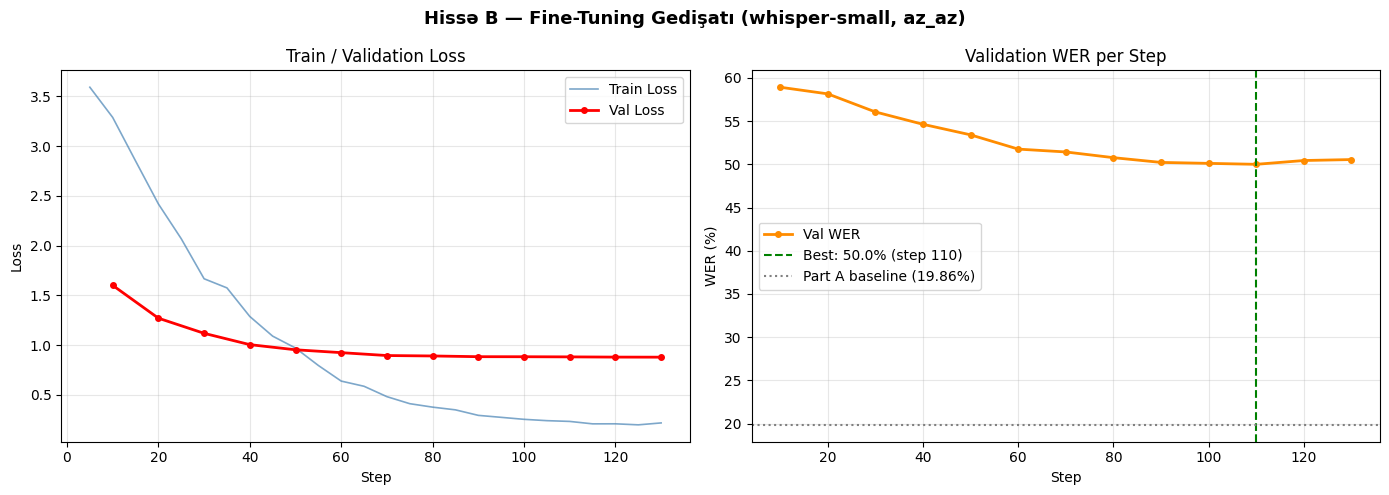

In [16]:
#Training qrafikləri 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hissə B — Fine-Tuning Gedişatı (whisper-small, az_az)',
             fontsize=13, fontweight='bold')

# 1) Train + Val Loss
ax1 = axes[0]
ax1.plot(train_steps, train_losses,
         color='steelblue', alpha=0.7, lw=1.2, label='Train Loss')
if eval_logs:
    ax1.plot(eval_steps, eval_losses,
             color='red', lw=2, marker='o', markersize=4, label='Val Loss')
ax1.set_xlabel('Step'); ax1.set_ylabel('Loss')
ax1.set_title('Train / Validation Loss')
ax1.legend(); ax1.grid(alpha=0.3)

# 2) Val WER per step
ax2 = axes[1]
if eval_logs:
    ax2.plot(eval_steps, eval_wers,
             color='darkorange', lw=2, marker='o', markersize=4, label='Val WER')
    best_idx = eval_wers.index(min(eval_wers))
    ax2.axvline(eval_steps[best_idx], color='green', linestyle='--', lw=1.5,
                label=f'Best: {min(eval_wers):.1f}% (step {eval_steps[best_idx]})')
    ax2.axhline(19.86, color='gray', linestyle=':', lw=1.5,
            label='Part A baseline (19.86%)')
ax2.set_xlabel('Step'); ax2.set_ylabel('WER (%)')
ax2.set_title('Validation WER per Step')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plot_path = f'{OUTPUT_DIR}/part_b_training.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

In [17]:
#Fine-tuned model ilə test inferens

print(f' Fine-tuned model test edilir ({TEST_SAMPLES} nümunə)...')
model.eval()

INFER_BATCH = 8
ft_refs, ft_hyps = [], []

for i in tqdm(range(0, len(test_data), INFER_BATCH), desc='FT inferens'):
    batch = test_data[i : i + INFER_BATCH]

    # input_features batch
    raw_features = [item['input_features'] for item in batch]
    padded = feature_extractor.pad(
        [{'input_features': f} for f in raw_features],
        return_tensors='pt'
    )
    input_features = padded['input_features'].to(DEVICE)
    input_features = input_features.to(dtype=next(model.parameters()).dtype)

    attention_mask = padded.get('attention_mask')
    if attention_mask is not None:
        attention_mask = attention_mask.to(DEVICE)

    with torch.no_grad():
        pred_ids = model.generate(
            input_features,
            attention_mask=attention_mask,  
            language=LANGUAGE_CODE,
            task='transcribe',
        )

    hyps = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)

    for item, hyp in zip(batch, hyps):
        ref = tokenizer.decode(
            [t for t in item['labels'] if t != -100],
            skip_special_tokens=True
        ).strip()
        ft_refs.append(normalize_az(ref))
        ft_hyps.append(normalize_az(hyp.strip()))

ft_wer_scores = [jwer(r, h) if r else 1.0 for r, h in zip(ft_refs, ft_hyps)]
ft_cer_scores = [jcer(r, h) if r else 1.0 for r, h in zip(ft_refs, ft_hyps)]

ft_mean_wer = np.mean(ft_wer_scores) * 100
ft_mean_cer = np.mean(ft_cer_scores) * 100

print(f'Fine-tuned — WER: {ft_mean_wer:.2f}% | CER: {ft_mean_cer:.2f}%')

 Fine-tuned model test edilir (100 nümunə)...


FT inferens:   0%|          | 0/13 [00:00<?, ?it/s]

Fine-tuned — WER: 44.01% | CER: 13.68%


In [18]:
#Müqayisə cədvəli 

BASELINE_WER = 19.86
BASELINE_CER = 4.76
BASELINE_MODEL = 'whisper-large-v3 (zero-shot)'
FT_MODEL       = f'whisper-small (fine-tuned, {TRAIN_SAMPLES} nümunə)'

comparison = pd.DataFrame({
    'Model'         : [BASELINE_MODEL, FT_MODEL],
    'WER (%)'       : [BASELINE_WER,  round(ft_mean_wer, 2)],
    'CER (%)'       : [BASELINE_CER,  round(ft_mean_cer, 2)],
    'Test nümunəsi' : [100, TEST_SAMPLES],
    'Train data'    : ['Yoxdur (zero-shot)', f'{TRAIN_SAMPLES} nümunə (az_az)'],
})

print('\nMÜQAYİSƏ CƏDVƏLİ:')
print('=' * 70)
print(comparison.to_string(index=False))
print('=' * 70)

wer_diff = ft_mean_wer - BASELINE_WER
print(f'\n  WER fərqi : {wer_diff:+.2f}%')

comparison.to_csv(f'{OUTPUT_DIR}/part_b_comparison.csv', index=False, encoding='utf-8-sig')


MÜQAYİSƏ CƏDVƏLİ:
                                 Model  WER (%)  CER (%)  Test nümunəsi         Train data
          whisper-large-v3 (zero-shot)    19.86     4.76            100 Yoxdur (zero-shot)
whisper-small (fine-tuned, 200 nümunə)    44.01    13.68            100 200 nümunə (az_az)

  WER fərqi : +24.15%


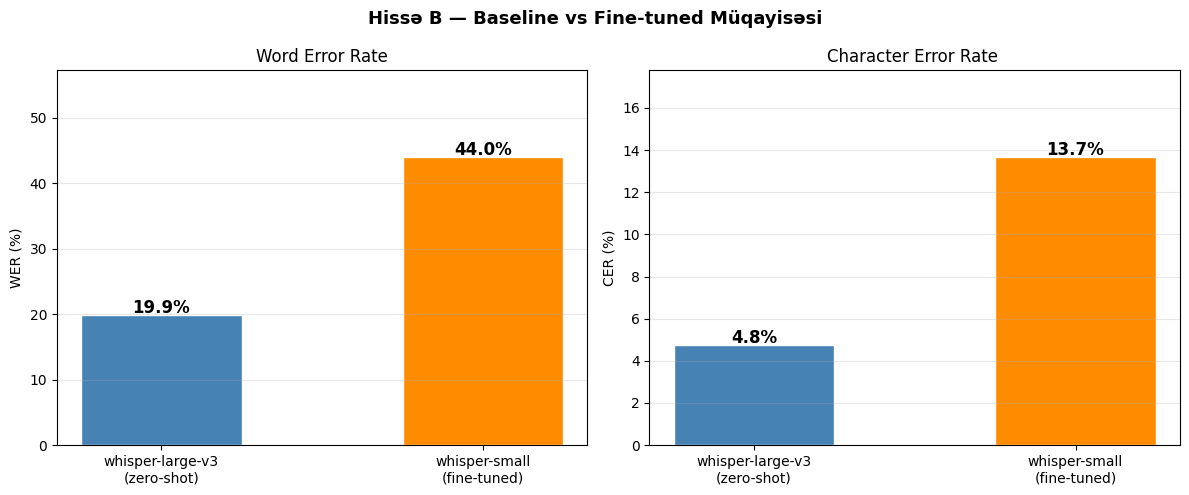

In [19]:
#Müqayisə qrafiki 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Hissə B — Baseline vs Fine-tuned Müqayisəsi',
             fontsize=13, fontweight='bold')

models   = ['whisper-large-v3\n(zero-shot)', 'whisper-small\n(fine-tuned)']
wer_vals = [BASELINE_WER, ft_mean_wer]
cer_vals = [BASELINE_CER, ft_mean_cer]
colors   = ['steelblue', 'darkorange']

ax1 = axes[0]
bars = ax1.bar(models, wer_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, wer_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax1.set_ylabel('WER (%)'); ax1.set_title('Word Error Rate')
ax1.set_ylim(0, max(wer_vals) * 1.3); ax1.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(models, cer_vals, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars2, cer_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel('CER (%)'); ax2.set_title('Character Error Rate ')
ax2.set_ylim(0, max(cer_vals) * 1.3); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
cmp_path = f'{OUTPUT_DIR}/part_b_comparison.png'
plt.savefig(cmp_path, dpi=150, bbox_inches='tight')
plt.show()

In [20]:
#Nəticələr 
result_info = {
    'ft_model'        : MODEL_ID,
    'baseline_model'  : 'openai/whisper-large-v3',
    'train_samples'   : TRAIN_SAMPLES,
    'val_samples'     : VAL_SAMPLES,
    'test_samples'    : TEST_SAMPLES,
    'epochs'          : NUM_EPOCHS,
    'eval_steps'      : EVAL_STEPS,
    'learning_rate'   : LEARNING_RATE,
    'ft_mean_wer'     : round(ft_mean_wer, 2),
    'ft_mean_cer'     : round(ft_mean_cer, 2),
    'baseline_wer'    : BASELINE_WER,
    'baseline_cer'    : BASELINE_CER,
    'wer_diff'        : round(ft_mean_wer - BASELINE_WER, 2),
}
with open(f'{OUTPUT_DIR}/part_b_results.json', 'w', encoding='utf-8') as f:
    json.dump(result_info, f, ensure_ascii=False, indent=2)

print(f'\nBaseline (large-v3, zero-shot):  WER={BASELINE_WER}%  CER={BASELINE_CER}%')
print(f'Fine-tuned (small, {TRAIN_SAMPLES} nümunə): WER={ft_mean_wer:.2f}%  CER={ft_mean_cer:.2f}%')
print(f'Fayllar: {OUTPUT_DIR}/')


Baseline (large-v3, zero-shot):  WER=19.86%  CER=4.76%
Fine-tuned (small, 200 nümunə): WER=44.01%  CER=13.68%
Fayllar: /kaggle/working/results_b/
